In [1]:
# Day 4 — Agentic AI & Multi-Agent Network Operations

In [2]:
# How can we build an AI-powered Network Operations Center (NOC) where AI agents can investigate network/infrastructure incidents autonomously, collaborate with specialist agents, recommend the right remediation, but still remain inside strict security and human-approval boundaries?

In [3]:
# Imagine a company like Walmart has a network/infrastructure problem:

# “Something is wrong. Maybe an application is slow, a network component is behaving incorrectly, or an infrastructure service is unhealthy.”

# Normally, a network engineer would manually do things like:
#     Incident comes → check monitoring → inspect configuration → check recent changes → look at documentation/issues → form possible root causes → validate them → recommend a fix.

# Can AI agents perform this investigation intelligently and systematically instead of an engineer manually jumping between ten different systems?

# But there is an important condition:
#     The AI should investigate and reason autonomously, but it should NOT blindly make production changes.

# That is really the central theme of the notebook.

In [4]:
# You can think of the notebook as building this system:

# Network Incident
# ↓
# AI Coordinator understands the incident
# ↓
# Collect evidence
# ↓
# Check monitoring
# ↓
# Check configuration
# ↓
# Check changes / documentation / known issues
# ↓
# Generate possible root causes
# ↓
# Validate those root causes
# ↓
# Different specialist AI agents collaborate
# ↓
# Recommend remediation
# ↓
# Security/Policy checks whether it is allowed
# ↓
# Human approval if required
# ↓
# Controlled execution
# ↓
# Validate whether the problem was fixed
# ↓
# Rollback or escalate if necessary

In [5]:
# Suppose the complaint is:
#   “Our checkout application has suddenly become slow.”

# Instead of asking one ChatGPT-like assistant:
# “Why is checkout slow?”

# an agentic system works differently.
# It may decide:
# Step 1: “I need monitoring data.”
# It calls the monitoring tool.
# Suppose monitoring data isn't available.
# The agent should not invent it.

# It records:
# Monitoring = UNAVAILABLE
# and continues investigating using other authorized evidence.

# Then it may decide:
# Step 2: “Let me inspect configuration.”

# Step 3: “Let me check recent known issues.”

# Step 4: “Let me check documentation.”

# Step 5: “Based on the evidence, these are the likely causes.”

# Then another agent may challenge that conclusion.

# Finally the system may recommend:
#   “The evidence suggests configuration X may be causing the issue. I recommend restoring configuration Y.”

# But that recommendation does not mean the AI changes the router/server.
# That is one of the most important ideas in this notebook:
# Recommendation ≠ Execution.

In [6]:
# Why Multi-Agent AI comes into the picture

# A single AI agent could potentially call every tool.

# But in a large enterprise NOC, different systems have different responsibilities and permissions.

# So the notebook introduces specialist agents such as agents responsible for things like:
#     Telemetry → Configuration → Topology → Knowledge → Root Cause Analysis → Security/Policy → Remediation → Validation → Coordination.

# The important idea is not simply giving ten agents fancy names.

# The notebook explicitly argues that separate agents are useful when they have genuinely different:
#     data access, tools, permissions, context, responsibilities, evaluation criteria, or failure boundaries.

# For example:
# Telemetry Agent
#     “I can inspect monitoring information, but I cannot modify infrastructure.”

# Configuration Agent
#     “I can inspect configuration information.”

# RCA Agent
#     “Give me the collected evidence and I will determine the most plausible root causes.”

# Security Policy Agent
#     “Even if the RCA agent suggests something, I determine whether that proposed action is permitted.”

# Remediation Agent
#     “I create the recommended fix, validation steps and rollback plan.”

# So one agent does not get unlimited power.

In [7]:
# Another major problem being solved: AI memory

# During a long network incident, an AI agent needs to remember things like:
#     “DNS was already checked.”
#     “Monitoring wasn't available.”
#     “Configuration evidence came from this source.”
#     “We are currently validating hypothesis #2.”

# But this introduces another risk.

# Imagine yesterday's incident information contaminating today's investigation.

# Therefore the notebook differentiates between:
#     short-term memory, persistent memory, workflow state and incident context.

# Essentially:
#     AI should remember what it needs, but only within the correct incident, environment and time boundary.

In [8]:
    #           NETWORK INCIDENT
    #                  ↓
    #          Coordinator Agent
    #                  ↓
    #        ┌─────────┼─────────┐
    #        ↓         ↓         ↓
    #    Telemetry   Config   Knowledge
    #     Agent      Agent      Agent
    #        └─────────┼─────────┘
    #                  ↓
    #               RCA Agent
    #                  ↓
    #          Possible Root Cause
    #                  ↓
    #         Security/Policy Agent
    #                  ↓
    #           Remediation Agent
    #                  ↓
    #       Validation / Challenge
    #                  ↓
    #            Human Approval
    #                  ↓
    #       Controlled Execution
    #                  ↓
    #     Validate → Rollback/Escalate

## Setup — stable, pinned, and offline-first

Tested together in the shared **`wal_net`** environment on Python 3.12.13 using the unified `requirements.txt`.

```bash
python3.12 -m venv wal_net
source wal_net/bin/activate          # Windows: wal_net\Scripts\activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name wal_net --display-name "Python (wal_net)"
```

Select the **Python (wal_net)** kernel in VS Code. Core LangGraph labs require no API key. The official OpenAI Agents SDK mapping is imported and instantiated locally; a live SDK run is separately guarded by three explicit environment settings.

In [9]:
from __future__ import annotations

import hashlib
import operator
import importlib.metadata as metadata
import json
import math
import os
import platform
import re
import sqlite3
import tempfile
import time
import uuid
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Annotated, Any, Callable, Literal, TypedDict

import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from pydantic import BaseModel, ConfigDict, Field, ValidationError, model_validator
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 120)
RANDOM_STATE = 42

print("Python:", platform.python_version())
print("Platform:", platform.platform())

Python: 3.12.13
Platform: macOS-26.6.2-arm64-arm-64bit


## Graph visualization helper

The essential LangGraph visualization pattern is:

```python
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))
```

`show_langgraph_figure()` applies that same pattern to every compiled graph in this notebook. PNG generation normally uses LangGraph’s Mermaid rendering service and therefore needs internet access. If that service is unavailable, the helper prints the Mermaid definition instead of failing the lesson.

In [10]:
def show_langgraph_figure(compiled_graph, title: str) -> None:
    '''Display a compiled LangGraph as a Mermaid PNG, with a safe text fallback.'''
    print(f"\n{title}")
    try:
        # User-requested visualization pattern:
        display(Image(compiled_graph.get_graph().draw_mermaid_png()))
    except Exception as exc:
        print(f"PNG rendering unavailable ({type(exc).__name__}). Mermaid source follows:")
        print(compiled_graph.get_graph().draw_mermaid())

In [11]:
EXPECTED = {
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "scikit-learn": "1.9.0",
    "pydantic": "2.13.4",
    "networkx": "3.6.1",
    "openai": "3.3.1",
    "openai-agents": "0.22.0",
    "langgraph": "1.2.11",
    "nbformat": "5.11.1",
    "nbclient": "0.11.0",
    "ipykernel": "7.3.0",
}
installed = {name: metadata.version(name) for name in EXPECTED}
version_check = pd.DataFrame(
    [
        {
            "package": name,
            "expected": expected,
            "installed": installed[name],
            "match": installed[name] == expected,
        }
        for name, expected in EXPECTED.items()
    ]
)
display(version_check)
assert tuple(map(int, platform.python_version_tuple()[:2])) >= (3, 12)
assert version_check["match"].all(), "Install the exact Session 4 requirements before continuing."
print("✓ Runtime matches the tested package set")

,package,expected,installed,match
0,numpy,2.5.2,2.5.2,True
1,pandas,3.0.5,3.0.5,True
2,scikit-learn,1.9.0,1.9.0,True
3,pydantic,2.13.4,2.13.4,True
4,networkx,3.6.1,3.6.1,True
5,openai,3.3.1,3.3.1,True
6,openai-agents,0.22.0,0.22.0,True
7,langgraph,1.2.11,1.2.11,True
8,nbformat,5.11.1,5.11.1,True
9,nbclient,0.11.0,0.11.0,True


✓ Runtime matches the tested package set


In [12]:
def locate_artifact(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path.cwd() / "outputs" / filename,
        Path.cwd().parent / "outputs" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Could not find {filename}. Checked: {candidates}")

CORPUS_PATH = locate_artifact("session3_walmart_network_corpus.jsonl")
MANIFEST_PATH = locate_artifact("session3_source_manifest.json")
records = [json.loads(line) for line in CORPUS_PATH.read_text().splitlines() if line.strip()]
manifest = json.loads(MANIFEST_PATH.read_text())

assert hashlib.sha256(CORPUS_PATH.read_bytes()).hexdigest() == manifest["corpus_sha256"]
assert len(records) == manifest["record_count"]
print(manifest["provenance_statement"])
print(f"✓ Loaded {len(records)} verified public records")

All operational facts and examples are sourced from public Walmart Global Tech or Walmart-originated L3AF project materials. No internal Walmart runbook, configuration, incident, topology, monitoring record, credential, or production state is claimed or fabricated.
✓ Loaded 81 verified public records


In [13]:
corpus_df = pd.DataFrame(records)
display(
    corpus_df.groupby("source_type", as_index=False)
    .agg(records=("doc_id", "count"), example=("title", "first"))
    .sort_values("records", ascending=False)
)

search_texts = (corpus_df["title"] + " " + corpus_df["content"]).tolist()
vectorizer = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), sublinear_tf=True)
corpus_matrix = vectorizer.fit_transform(search_texts)

def search_corpus(query: str, top_k: int = 5, source_types: set[str] | None = None) -> list[dict[str, Any]]:
    if not query.strip():
        raise ValueError("query must not be empty")
    scores = cosine_similarity(vectorizer.transform([query]), corpus_matrix).ravel()
    mask = np.ones(len(corpus_df), dtype=bool)
    if source_types:
        mask = corpus_df["source_type"].isin(source_types).to_numpy()
    candidates = np.where(mask)[0]
    ranked = candidates[np.argsort(scores[candidates])[::-1]][:top_k]
    return [
        {
            **corpus_df.iloc[i].to_dict(),
            "score": float(scores[i]),
        }
        for i in ranked
    ]

display(pd.DataFrame(search_corpus("BPFRunning metric loading error", 3))[["doc_id", "score", "title", "source_url"]])

,source_type,records,example
4,historical_issue,37,L3AFD issue #754: Build failure on Cilium eBPF package upgrade
3,configuration_standard,12,configdoc: L3AFD Config Options Documentation
2,configuration_repository,10,l3afd sample configuration: [l3afd]
9,project_readme,9,README: L3AFD: Lightweight eBPF Daemon
6,operational_runbook,5,graceful-restart-guide: Prerequisites
8,production_deployment_guide,3,prod-deploy-guide: Installing l3afd
7,package_repository_guide,2,README: eBPF Package Repository
0,api_specification,1,l3afd REST API operation inventory
1,change_records,1,L3AFD recent public commit history
5,official_walmart_global_tech_article,1,Walmart Global Tech: published network scale and open-source context


,doc_id,score,title,source_url
0,l3afd-issue-698,0.295954,L3AFD issue #698: l3afd_BPFRunning metric reports true incase of ebpf_program loading error,https://github.com/l3af-project/l3afd/issues/698
1,l3afd-issue-523,0.129092,L3AFD issue #523: Add metrics to count ebpf program loading failure errors,https://github.com/l3af-project/l3afd/issues/523
2,l3afd-issue-637,0.080799,L3AFD issue #637: Remove stale metric reporting on eBPF program unload,https://github.com/l3af-project/l3afd/issues/637


# Module 1 — From GenAI Copilot to Agentic AI

## 1.1 LLM vs chatbot vs copilot vs AI agent

| System | Primary behavior | Initiative | Tools/state | Network example |
|---|---|---:|---|---|
| LLM | predicts a response from context | none | not inherent | explain OSPF adjacency states |
| Chatbot | manages a conversation around an LLM | reactive | conversation history | answer a NetOps FAQ |
| Copilot | assists a human in a workflow | suggestive | often retrieval/tools | propose diagnostic commands |
| AI agent | pursues a goal through a controlled loop | bounded initiative | tools, state, stopping rules | gather evidence and produce a validated investigation |

The difference is not personality. An agent has a **goal, an environment, observations, allowed actions, state, feedback, and termination conditions**.

**Trainer distinction:** a model may recommend a tool call; deterministic code still validates identity, arguments, authorization, execution, and result handling.

### Concept-by-concept operational intuition

| Concept | Simple explanation | Network/infrastructure example | Why it matters |
|---|---|---|---|
| Agent goal | The outcome the workflow is trying to reach | Determine the most supported cause of checkout latency | Prevents endless exploration |
| Instructions | Rules describing how the goal may be pursued | Read-only diagnostics; cite evidence; stop before change | Defines behavior but is reinforced by code |
| Reasoning | Interpret observations and identify what remains unknown | DNS succeeds, so investigate path/firewall evidence next | Converts raw signals into a justified next question |
| Planning | Order safe actions under time and step budgets | Check monitoring, configuration and recent changes | Avoids random or repeated tool use |
| Tools | Approved capabilities exposed to the workflow | `query_monitoring()` or `retrieve_configuration()` | Connects language reasoning to authoritative systems |
| Memory | Information deliberately retained beyond one step | Remember that a route lookup was already completed | Reduces repetition, but creates freshness and privacy risk |
| State | Explicit current workflow truth | Status, evidence IDs, step count and approval flag | Makes execution resumable and testable |
| Observation | A returned fact or failure from the environment | “BGP session up at 10:02 UTC” or “monitoring unavailable” | Evidence—not model belief—should drive conclusions |
| Action | A bounded operation selected by the workflow | Invoke a read-only interface-status tool | Must stay inside permission and blast-radius boundaries |
| Feedback loop | Validation changes the next step | Missing time-aligned logs routes the graph back to collection | Lets the workflow adapt without looping forever |
| Workflow pattern | Reusable control-flow shape | Router, tool loop, manager-specialists or approval state machine | Helps choose a design engineers can operate |

In [14]:
system_comparison = pd.DataFrame(
    [
        {"system": "LLM", "goal_loop": False, "tools": False, "state": False, "acts": False},
        {"system": "Chatbot", "goal_loop": False, "tools": "optional", "state": "conversation", "acts": False},
        {"system": "Copilot", "goal_loop": "human-led", "tools": True, "state": "workflow", "acts": "usually proposes"},
        {"system": "Agent", "goal_loop": "bounded autonomous", "tools": True, "state": "explicit", "acts": "within policy"},
    ]
)
display(system_comparison)

,system,goal_loop,tools,state,acts
0,LLM,False,False,False,False
1,Chatbot,False,optional,conversation,False
2,Copilot,human-led,True,workflow,usually proposes
3,Agent,bounded autonomous,True,explicit,within policy


## 1.2 Agent goals and instructions

“Troubleshoot the network” is not an operational goal. A usable agent contract specifies:

- the outcome and success criteria;
- the evidence domain and authoritative sources;
- allowed tools and targets;
- prohibited actions;
- uncertainty and citation requirements;
- time, step, cost, and retry budgets;
- approval and escalation boundaries;
- stopping conditions.

Keep goals outcome-oriented and instructions behavior-oriented. Policy must remain enforceable outside the model.

In [15]:
# defining a contract/rulebook for our troubleshooting AI agent.

class AgentContract(BaseModel):
    model_config = ConfigDict(extra="forbid")

    name: str
    goal: str
    success_criteria: list[str]
    allowed_tools: set[str]
    prohibited_actions: list[str]
    max_steps: int = Field(ge=1, le=20)
    requires_citations: bool = True
    human_gate_before_write: bool = True

# Sample
# success_criteria = [
#     "required evidence categories are attempted",
#     "hypotheses are labeled by support status",
#     "missing live context is explicit",
#     "recommendation contains no unauthorized execution",
# ]


# Now we create an actual agent contract
troubleshooting_contract = AgentContract(
    name="Public L3AF Evidence Investigator",
    goal="Produce a source-attributed investigation of a public L3AF issue without claiming live access.",
    success_criteria=[
        "required evidence categories are attempted",
        "hypotheses are labeled by support status",
        "missing live context is explicit",
        "recommendation contains no unauthorized execution",
    ],
    allowed_tools={
        "collect_incident_evidence",
        "query_monitoring",
        "inspect_configuration",
        "check_changes",
        "retrieve_knowledge",
    },
    prohibited_actions=["execute shell commands", "change infrastructure", "invent live telemetry"],
    max_steps=10,
)
print(troubleshooting_contract.model_dump_json(indent=2))

{
  "name": "Public L3AF Evidence Investigator",
  "goal": "Produce a source-attributed investigation of a public L3AF issue without claiming live access.",
  "success_criteria": [
    "required evidence categories are attempted",
    "hypotheses are labeled by support status",
    "missing live context is explicit",
    "recommendation contains no unauthorized execution"
  ],
  "allowed_tools": [
    "collect_incident_evidence",
    "inspect_configuration",
    "query_monitoring",
    "check_changes",
    "retrieve_knowledge"
  ],
  "prohibited_actions": [
    "execute shell commands",
    "change infrastructure",
    "invent live telemetry"
  ],
  "max_steps": 10,
  "requires_citations": true,
  "human_gate_before_write": true
}


## 1.3 Reasoning and planning; tools; memory and state

An enterprise agent should expose **decision summaries**, not private chain-of-thought. For every step, record:

- observation received;
- evidence gap detected;
- action selected and why it is allowed;
- tool result and source identifiers;
- state transition;
- validation outcome;
- stop/escalation reason.

Tools connect the agent to evidence or action. Memory carries information across turns. State represents the workflow’s explicit truth. Mixing them causes hard-to-debug behavior: a conversation summary is not a CMDB, an old tool result is not current telemetry, and a model belief is not an observed fact.

## 1.4 Observations and actions; feedback loops

```text
goal
  ↓
observe environment/evidence
  ↓
decide next bounded action
  ↓
invoke approved tool
  ↓
validate result and update state
  ├─ enough supported evidence → recommend and stop
  ├─ missing evidence → continue within budget
  └─ unsafe/blocked/ambiguous → escalate
```

Feedback is useful only if it changes the next decision. Validation must test evidence completeness, policy compliance, output schema, and operational applicability—not merely ask another model “does this look right?”

## 1.5 Agentic workflow patterns

| Pattern | Shape | Strong fit | Main risk |
|---|---|---|---|
| Tool-use loop | observe → tool → observe | interactive diagnosis | loops/repeated calls |
| Plan-and-execute | plan first, execute bounded steps | stable procedures | brittle plan after new evidence |
| Router | classify then delegate | clear domains | misrouting |
| Manager + specialists | coordinator calls agents as tools | one owner synthesizes | coordinator bottleneck |
| Handoff | specialist takes over | focused ownership | context/permission leakage |
| Parallel fan-out/fan-in | independent tasks concurrently | config + topology + telemetry | costly/noisy merge |
| Evaluator–optimizer | generate → critique → revise | reports/plans | self-confirming feedback |
| State machine | deterministic allowed transitions | regulated remediation | less flexible |

Mature systems mix patterns: deterministic code owns policy and lifecycle; a model handles semantic selection and synthesis inside those rails.

# Module 2 — Agentic Network Investigation

## 2.1 The operational reasoning loop

**Observe → Reason → Plan → Act → Validate**

- **Observe:** collect new facts and tool results.
- **Reason:** identify evidence gaps and decision constraints.
- **Plan:** select the smallest safe next step.
- **Act:** invoke one approved capability with validated arguments.
- **Validate:** test the result, update state, and decide whether to stop.

Operational workflow:

**Incident → Collect Evidence → Query Monitoring → Inspect Configuration → Check Changes → Retrieve Knowledge → Generate Hypotheses → Validate → Recommend**

## 2.2 LangGraph from first principles

LangGraph is an orchestration framework for long-running, stateful workflows and agents. It does not magically make an LLM autonomous. It gives engineers explicit control over **what can happen next**.

Think of a network troubleshooting workflow as a controlled packet journey:

| LangGraph concept | Plain meaning | Infrastructure analogy |
|---|---|---|
| State | Shared typed record carried through the workflow | Incident record containing evidence, status and approvals |
| Node | A Python function that reads state and returns updates | Monitoring query, configuration check or RCA step |
| Edge | An allowed transition between nodes | Runbook transition from evidence collection to validation |
| Conditional edge | Runtime routing decision | If severity is critical, escalate; otherwise continue diagnosis |
| Loop | Revisit a node until a stopping condition holds | Poll telemetry until enough samples arrive or the budget expires |
| Checkpointer | Saves thread-scoped state after steps | Incident checkpoint used to resume after a pause or failure |
| Interrupt | Pauses execution for external input | Human approval before a controlled action |
| Command | Resumes or redirects execution | Approval response that continues the saved workflow |

The engineering sequence is always the same:

**Define state → write small nodes → connect edges → compile → invoke with input → inspect final state**

Why use a graph instead of a large `while` loop? The graph makes legal transitions, branches, cycles, checkpoints and human gates visible and testable. Business policy still belongs in deterministic code; the model may assist with semantic decisions inside those boundaries.

| Block                | Simple meaning                                                       | Real-life network example                                                                                     |
| -------------------- | -------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **State**            | The common information carried throughout the workflow.              | One incident record containing the alert, logs, configuration findings, RCA status, and approvals.            |
| **Node**             | One specific task/function in the workflow.                          | One node checks monitoring, another checks configuration, another performs RCA.                               |
| **Edge**             | The path connecting one step to the next.                            | After collecting evidence → go to configuration check → then go to RCA.                                       |
| **Conditional Edge** | Decide the next path based on a condition.                           | If severity = critical → escalate to human; otherwise → continue investigation.                               |
| **Loop**             | Repeat a step until a condition is satisfied.                        | Keep checking CPU/network metrics every few minutes until enough evidence is collected.                       |
| **Checkpointer**     | Saves the current progress so the workflow can continue later.       | Investigation reaches step 6, system crashes; after restart it resumes from step 6 instead of starting again. |
| **Interrupt**        | Pause the workflow and wait for external/human input.                | AI recommends restarting a production service, so execution pauses and waits for engineer approval.           |
| **Command**          | Instruction that tells the workflow how to continue after the pause. | Engineer clicks **Approve**, so the command tells LangGraph to continue to the remediation step.              |


In [ ]:
# State = what we know
# Node = what we do
# Edge = where we go next
# Conditional Edge = which direction we choose
# Loop = repeat
# Checkpointer = save progress
# Interrupt = pause for someone
# Command = continue/resume

### Example A — Linear shared-state flow

A linear graph is the easiest mental model: intake receives an incident, normalization creates a consistent representation, and summary produces the handoff. Every node receives the same state schema and returns only its updates.

,input,normalized,summary,node_outputs
0,DC-07 inventory API is intermittently unreachable,dc-07 inventory api is intermittently unreachable,Network incident received: dc-07 inventory api is intermittently unreachable,intake accepted → incident normalized → summary created
1,STORE-1842 access point reports high channel utilization,store-1842 access point reports high channel utilization,Network incident received: store-1842 access point reports high channel utilization,intake accepted → incident normalized → summary created
2,Cloud load balancer health checks are timing out,cloud load balancer health checks are timing out,Network incident received: cloud load balancer health checks are timing out,intake accepted → incident normalized → summary created



Figure A — Linear intake workflow


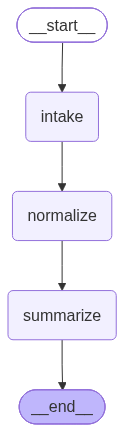

In [ ]:
# Define the shared state
class LinearState(TypedDict):
    incident: str # original problem reported
    normalized: str # cleaned version of the incident text
    summary: str # final summary
    events: Annotated[list[str], operator.add] # list of what steps were completed

# incident = " DC-07 API is DOWN "
# normalized = "dc-07 api is down"
# summary = "Network incident received: dc-07 api is down"
# events = ["intake accepted", "incident normalized", "summary created"]

# events: Annotated[list[str], operator.add]
# This means when different nodes return new events, LangGraph should add/append them together, rather than replacing the previous list.


# It receives the current state and simply records:
#     “The incident has been accepted.”
# It does not change the incident itself.
def linear_intake(state: LinearState) -> dict:
    return {"events": ["intake accepted"]}

# Its job is to clean the incoming incident text.
def linear_normalize(state: LinearState) -> dict:
    normalized = re.sub(r"\s+", " ", state["incident"].strip()).lower()
    return {"normalized": normalized, "events": ["incident normalized"]}
# "  DC-07 inventory API is intermittently unreachable  "
# .strip()
# Removes extra spaces at the beginning and end.
# "DC-07 inventory API is intermittently unreachable"
# re.sub(r"\s+", " ", ...)
# If there are multiple spaces inside the sentence, replace them with one space.
# "DC-07   inventory   API" -> "DC-07 inventory API"

# It creates a final summary using the normalized incident.
def linear_summarize(state: LinearState) -> dict:
    return {
        "summary": f"Network incident received: {state['normalized']}",
        "events": ["summary created"],
    }

linear_builder = StateGraph(LinearState)
linear_builder.add_node("intake", linear_intake)
linear_builder.add_node("normalize", linear_normalize)
linear_builder.add_node("summarize", linear_summarize)
linear_builder.add_edge(START, "intake")
linear_builder.add_edge("intake", "normalize")
linear_builder.add_edge("normalize", "summarize")
linear_builder.add_edge("summarize", END)
linear_graph = linear_builder.compile()

linear_examples = [
    "  DC-07 inventory API is intermittently unreachable  ",
    "STORE-1842 access point reports high channel utilization",
    "Cloud load balancer health checks are timing out",
]
linear_results = []
for example in linear_examples:
    result = linear_graph.invoke({
        "incident":example, "normalized":"", "summary":"", "events":[],
    })
    linear_results.append({
        "input":example.strip(), "normalized":result["normalized"],
        "summary":result["summary"], "node_outputs":" → ".join(result["events"]),
    })

display(pd.DataFrame(linear_results))
show_langgraph_figure(linear_graph, "Figure A — Linear intake workflow")
assert all(row["node_outputs"].endswith("summary created") for row in linear_results)

### Example B — Conditional branch

A branch represents an explicit operating decision. Here the classifier is deterministic and auditable: critical incidents follow an urgent path; other incidents follow the standard path. In production the model may propose severity, but policy validates it before routing.

,severity,route,response,events
0,SEV1,urgent,Open incident bridge and page the on-call lead.,classified as urgent → urgent path
1,SEV2,standard,Queue bounded diagnostic collection.,classified as standard → standard path
2,SEV3,standard,Queue bounded diagnostic collection.,classified as standard → standard path



Figure B — Conditional severity branch


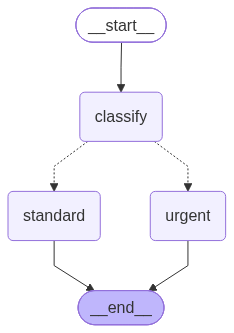

In [17]:
class BranchState(TypedDict):
    severity: str
    route: str
    response: str
    events: Annotated[list[str], operator.add]

def classify_severity(state: BranchState) -> dict:
    route = "urgent" if state["severity"].upper() in {"SEV0", "SEV1"} else "standard"
    return {"route": route, "events": [f"classified as {route}"]}

def urgent_path(state: BranchState) -> dict:
    return {"response": "Open incident bridge and page the on-call lead.", "events": ["urgent path"]}

def standard_path(state: BranchState) -> dict:
    return {"response": "Queue bounded diagnostic collection.", "events": ["standard path"]}

branch_builder = StateGraph(BranchState)
branch_builder.add_node("classify", classify_severity)
branch_builder.add_node("urgent", urgent_path)
branch_builder.add_node("standard", standard_path)
branch_builder.add_edge(START, "classify")
branch_builder.add_conditional_edges("classify", lambda s: s["route"], {"urgent":"urgent", "standard":"standard"})
branch_builder.add_edge("urgent", END)
branch_builder.add_edge("standard", END)
branch_graph = branch_builder.compile()

branch_results = []
for severity in ["SEV1", "SEV2", "SEV3"]:
    result = branch_graph.invoke({"severity":severity, "route":"", "response":"", "events":[]})
    branch_results.append({"severity":severity, "route":result["route"],
                           "response":result["response"], "events":" → ".join(result["events"])})

display(pd.DataFrame(branch_results))
show_langgraph_figure(branch_graph, "Figure B — Conditional severity branch")
assert {row["route"] for row in branch_results} == {"urgent", "standard"}

### Example C — Bounded loop

Agents often need another observation. A safe loop has a measurable completion condition and a hard budget. This example collects at most three samples; it cannot poll forever.

,max_attempts,actual_attempts,samples,enough_evidence,stop_reason
0,2,2,"[95, 90]",False,attempt budget exhausted
1,3,3,"[95, 90, 85]",True,three samples collected
2,5,3,"[95, 90, 85]",True,three samples collected



Figure C — Bounded evidence-collection loop


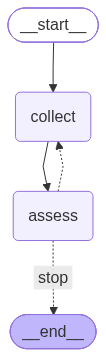

In [ ]:
class LoopState(TypedDict):
    attempts: int # how many samples have already been collected.
    max_attempts: int # maximum number of tries allowed.
    samples: Annotated[list[int], operator.add] # collected monitoring values.
    enough_evidence: bool # whether we have collected enough information.
    stop_reason: str # why the loop stopped.
# attempts = 2
# max_attempts = 3
# samples = [95, 90]
# enough_evidence = False
# stop_reason = "need another sample"

# This node simulates collecting one monitoring sample.
def collect_sample(state: LoopState) -> dict:
    next_attempt = state["attempts"] + 1
    return {"attempts": next_attempt, "samples": [100 - 5 * next_attempt]}

# Assess whether we have enough evidence
def assess_samples(state: LoopState) -> dict:
    enough = len(state["samples"]) >= 3
    exhausted = state["attempts"] >= state["max_attempts"]
    reason = "three samples collected" if enough else ("attempt budget exhausted" if exhausted else "need another sample")
    return {"enough_evidence": enough, "stop_reason": reason}

# Routing decision
def route_loop(state: LoopState) -> str:
    return "stop" if state["enough_evidence"] or state["attempts"] >= state["max_attempts"] else "collect"

loop_builder = StateGraph(LoopState)
loop_builder.add_node("collect", collect_sample)
loop_builder.add_node("assess", assess_samples)
loop_builder.add_edge(START, "collect")
loop_builder.add_edge("collect", "assess")
loop_builder.add_conditional_edges("assess", route_loop, {"collect":"collect", "stop":END})
loop_graph = loop_builder.compile()

loop_results = []
for max_attempts in [2, 3, 5]:
    result = loop_graph.invoke(
        {"attempts":0, "max_attempts":max_attempts, "samples":[],
         "enough_evidence":False, "stop_reason":""},
        config={"recursion_limit":20},
    )
    loop_results.append({"max_attempts":max_attempts, "actual_attempts":result["attempts"],
                         "samples":result["samples"], "enough_evidence":result["enough_evidence"],
                         "stop_reason":result["stop_reason"]})

display(pd.DataFrame(loop_results))
show_langgraph_figure(loop_graph, "Figure C — Bounded evidence-collection loop")
assert loop_results[0]["stop_reason"] == "attempt budget exhausted"
assert loop_results[1]["enough_evidence"] and loop_results[2]["actual_attempts"] == 3

### Example D — Human-in-the-loop interrupt and resume

LangGraph `interrupt()` pauses a node and stores the thread state through a checkpointer. The application displays the JSON-safe approval request. The same `thread_id` is then resumed with `Command(resume=...)`. Code before an interrupt can execute again after resumption, so side effects must occur only after approval and must be idempotent.

,action,requested_approval,interrupt_payload,final_status,events
0,validate a route-policy dry run,True,"{'question': 'Approve dry-run validation?', 'action': 'validate a route-policy dry run'}",DRY_RUN_COMPLETE,proposal created → human decision received → dry-run executed
1,restart a production edge router,False,"{'question': 'Approve dry-run validation?', 'action': 'restart a production edge router'}",CANCELLED,proposal created → human decision received → request cancelled



Figure D — Human approval interrupt and resume


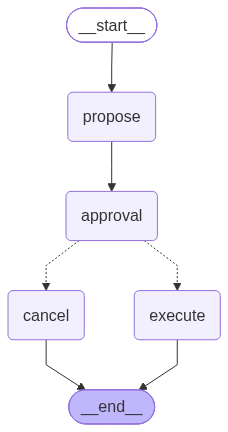

In [ ]:
# AI proposes an action → workflow pauses → human approves/rejects → same workflow resumes → execute or cancel

class IntroApprovalState(TypedDict):
    action: str # what action is being requested.
    approved: bool | None # True, False, or None before the human decides.
    status: str # current workflow status.
    events: Annotated[list[str], operator.add] # history of what happened.
# action = "validate a route-policy dry run"
# approved = None
# status = "NEW"
# events = []

# Proposal node - “The proposed action is ready, but it needs approval.”
def propose_action(state: IntroApprovalState) -> dict:
    return {"status":"PENDING_APPROVAL", "events":["proposal created"]}

# Human approval node - This node is responsible for asking a human.
def request_intro_approval(state: IntroApprovalState) -> dict:
    response = interrupt({"question":"Approve dry-run validation?", "action":state["action"]})
    return {"approved":bool(response.get("approved", False)), "events":["human decision received"]}
# interrupt() tells LangGraph:
# Pause the workflow here and wait for external input.
# The human/application will receive something like:
# Question:
# Approve dry-run validation?

# Action:
# validate a route-policy dry run
# At this moment, the graph stops temporarily.
# It does not continue to execute.

# Execution node - If the human approves, this node runs.
def intro_execute(state: IntroApprovalState) -> dict:
    return {"status":"DRY_RUN_COMPLETE", "events":["dry-run executed"]}

# Cancel node - If the human rejects, this node runs.
def intro_cancel(state: IntroApprovalState) -> dict:
    return {"status":"CANCELLED", "events":["request cancelled"]}

intro_builder = StateGraph(IntroApprovalState)
intro_builder.add_node("propose", propose_action)
intro_builder.add_node("approval", request_intro_approval)
intro_builder.add_node("execute", intro_execute)
intro_builder.add_node("cancel", intro_cancel)
intro_builder.add_edge(START, "propose")
intro_builder.add_edge("propose", "approval")
intro_builder.add_conditional_edges("approval", lambda s: "execute" if s["approved"] else "cancel", {"execute":"execute", "cancel":"cancel"})
intro_builder.add_edge("execute", END)
intro_builder.add_edge("cancel", END)
intro_graph = intro_builder.compile(checkpointer=InMemorySaver())

def run_intro_approval_example(thread_id: str, action: str, approve: bool) -> dict:
    config = {"configurable":{"thread_id":thread_id}}
    paused = intro_graph.invoke(
        {"action":action, "approved":None, "status":"NEW", "events":[]}, config=config,
    )
    payload = paused["__interrupt__"][0].value
    resumed = intro_graph.invoke(Command(resume={"approved":approve}), config=config)
    return {"action":action, "requested_approval":approve, "interrupt_payload":payload,
            "final_status":resumed["status"], "events":" → ".join(resumed["events"])}

intro_results = [
    run_intro_approval_example("day4-intro-approve", "validate a route-policy dry run", True),
    run_intro_approval_example("day4-intro-reject", "restart a production edge router", False),
]
display(pd.DataFrame(intro_results))
show_langgraph_figure(intro_graph, "Figure D — Human approval interrupt and resume")
assert [row["final_status"] for row in intro_results] == ["DRY_RUN_COMPLETE", "CANCELLED"]